# Condition langleys

In [1]:
import atmPy.radiation.retrievals.langley_calibration as atmlc
import helpers

In [2]:
prefix = '/Users/htelg'
serialno = 648
version = '0.6'

In [3]:
reload(atmlc)

<module 'atmPy.radiation.retrievals.langley_calibration' from '/Users/htelg/prog/atm-py/atmPy/radiation/retrievals/langley_calibration.py'>

In [4]:
p2fld = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/{serialno}.langleys/v{version}/')
lt = atmlc.open_langleys(p2fld, pattern='langley*.nc')

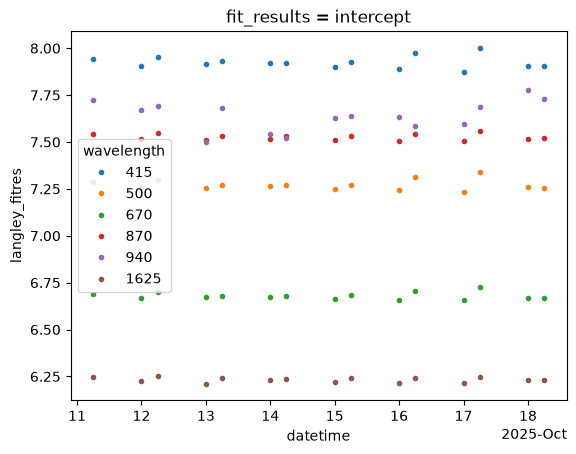

In [5]:
out = lt.dataset.langley_fitres.sel(fit_results = 'intercept').plot.line(x = 'datetime', ls = '', marker = '.')

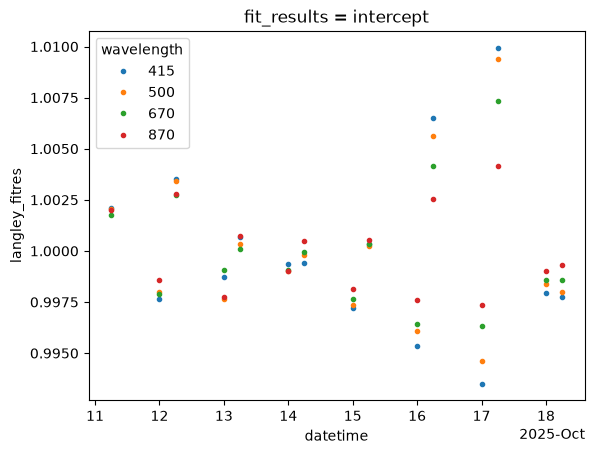

In [6]:
# any sudden steps?
bla = lt.dataset.langley_fitres.sel(fit_results = 'intercept', wavelength = [415, 500, 670, 870])
bla /= bla.mean('datetime')
out = bla.plot.line(x = 'datetime', ls = '', marker = '.')

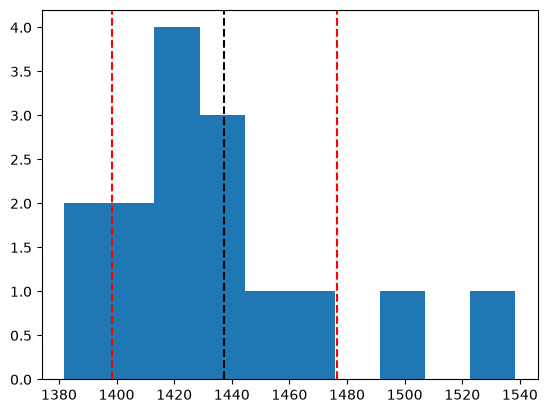

In [7]:
f,a = plt.subplots()
v0s = lt.dataset.langley_fitres.sel(wavelength = 500, fit_results = 'intercept')
v0s = np.exp(v0s)
a.hist(v0s, bins = 10)
a.axvline(v0s.mean(), ls = '--', color = 'black')
a.axvline(v0s.mean() + v0s.std(), ls = '--', color = 'red')
a.axvline(v0s.mean() - v0s.std(), ls = '--', color = 'red')

## remove outliers

In [8]:
import copy

## at individual stderr

In [9]:
lttrunc = copy.deepcopy(lt)
ds = lttrunc.dataset
# remove largest stderr
stderr = ds.langley_fitres.sel(fit_results = 'intercept_stderr')
lttrunc.dataset['langley_fitres'] = ds.langley_fitres.where(stderr < stderr.quantile(0.9, dim = 'datetime'))

# remove outliers based on quantiles
ds = lttrunc.dataset
interc = ds.langley_fitres.sel(fit_results = 'intercept')
where = np.logical_and(interc.quantile(0.1, dim = 'datetime') < interc, interc < interc.quantile(0.9, dim = 'datetime'))
lttrunc.dataset['langley_fitres'] = ds.langley_fitres.where(where)

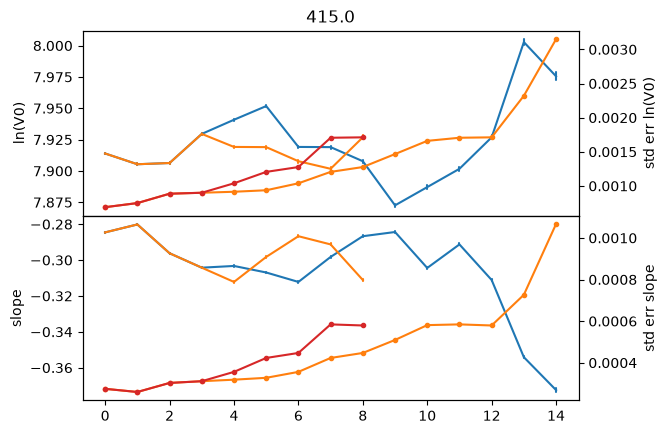

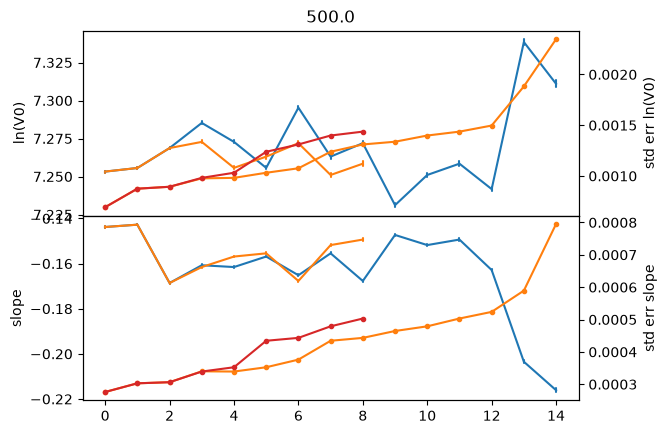

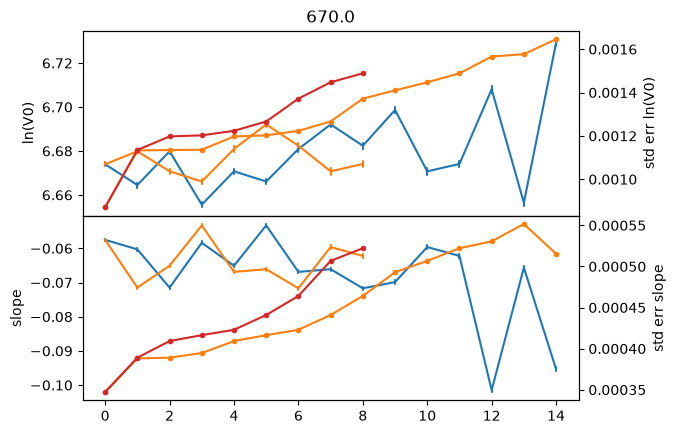

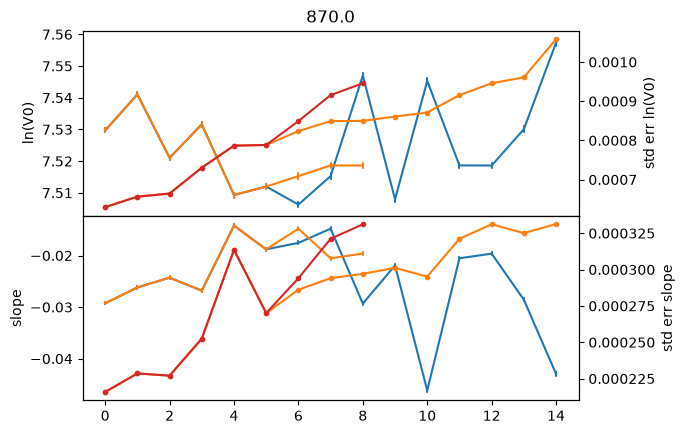

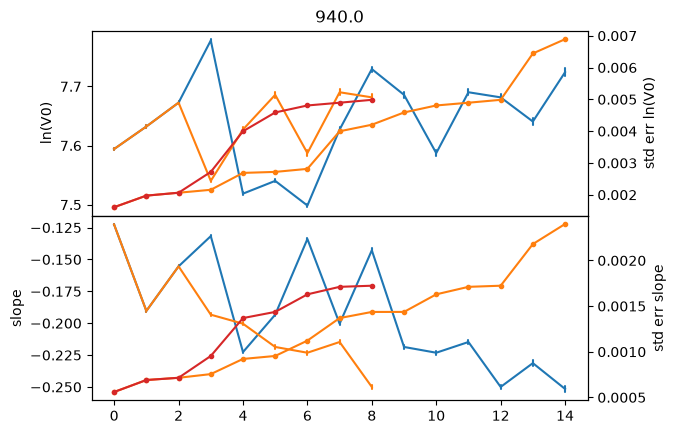

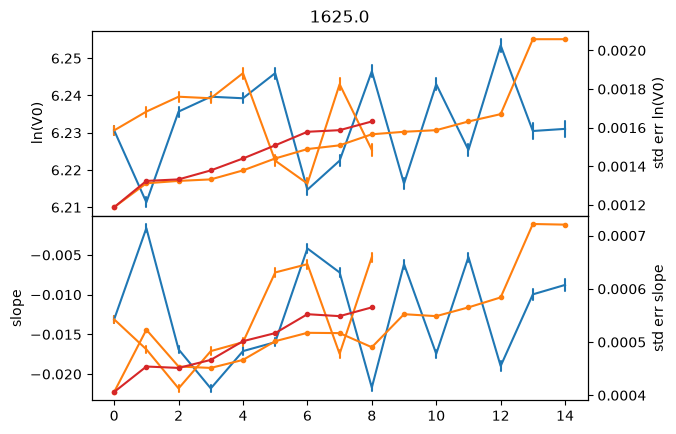

In [10]:
# all sorted by the stderr of the individual channel
wls = lt.dataset.wavelength
for wl in wls:
    f,aa = lt.plot_sorted(wl = wl, wlsort=wl)
    f,aa = lttrunc.plot_sorted(wl = wl, wlsort=wl, aa = aa)
    # aa
    aa[0].set_title(float(wl))

In [11]:
lt.V0_simple.OD_uncertainty

<xarray.DataArray 'OD_uncertainty' (wavelength: 6)> Size: 48B
array([0.05432439, 0.04610716, 0.03432021, 0.02825233, 0.12181912,
       0.02336715])
Coordinates:
  * wavelength  (wavelength) int64 48B 415 500 670 870 940 1625
Attributes:
    description:  (V0_std / V0 * osub) + 0.005. osub: one-sided upper bound f...

In [12]:
lttrunc.V0_simple.OD_uncertainty

<xarray.DataArray 'OD_uncertainty' (wavelength: 6)> Size: 48B
array([0.02191359, 0.01914989, 0.01847425, 0.02263307, 0.09400774,
       0.02219522])
Coordinates:
  * wavelength  (wavelength) int64 48B 415 500 670 870 940 1625
    quantile    float64 8B 0.9
Attributes:
    description:  (V0_std / V0 * osub) + 0.005. osub: one-sided upper bound f...

In [13]:
lttrunc.V0_simple.V0_std/lttrunc.V0_simple.V0

<xarray.DataArray (wavelength: 6)> Size: 48B
array([0.00988512, 0.00826988, 0.007875  , 0.01030562, 0.05202041,
       0.01004971])
Coordinates:
  * wavelength  (wavelength) int64 48B 415 500 670 870 940 1625
    quantile    float64 8B 0.9
Attributes:
    description:  nbiased standard deviation, ddof = 1

# pwv

In [14]:
p2fld = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/{serialno}.langleys/v{version}/')


In [15]:
reload(helpers)

<module 'helpers' from '/Users/htelg/projects/cmpaign_2025_PMOD/helpers.py'>

In [16]:
pwvi = helpers.open_pwvcals(p2fld, pattern = 'pwv*.nc')

In [17]:
# i had a spelling error in earlier versions, this can be deleted passt v0.6
pwvi.dataset = pwvi.dataset.assign_coords(statistic=['estimate','uncertainty'])

Text(0.5, 1.0, 'V0 trend')

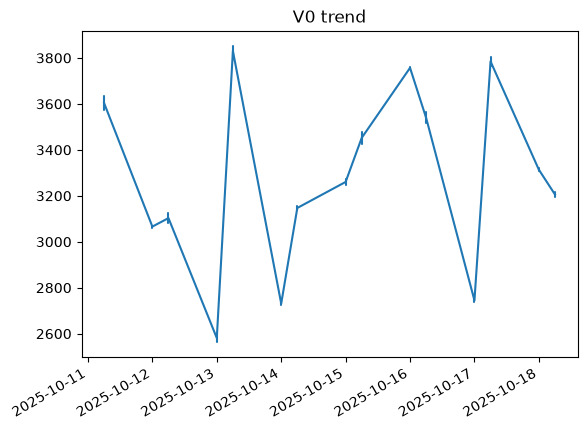

In [18]:
data = pwvi.dataset.fitres.sel(statistic = 'estimate', parameter = 'V0')
error = pwvi.dataset.fitres.sel(statistic = 'uncertainty', parameter = 'V0')

f, a = plt.subplots()
a.errorbar(data.datetime, data, yerr=error)
f.autofmt_xdate()
a.set_title('V0 trend')

Text(0.5, 1.0, 'V0 trend - compared to 415n for variability comp.')

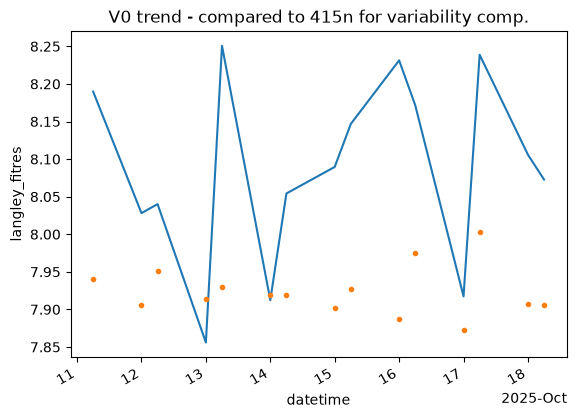

In [19]:
data = pwvi.dataset.fitres.sel(statistic = 'estimate', parameter = 'V0')
error = pwvi.dataset.fitres.sel(statistic = 'uncertainty', parameter = 'V0')

f, a = plt.subplots()
a.plot(data.datetime, np.log(data))
lt.dataset.langley_fitres.sel(fit_results = 'intercept', wavelength = 415).plot(ax = a, marker = '.', ls = '')
f.autofmt_xdate()
# a.set_yscale('log')
a.set_title('V0 trend - compared to 415n for variability comp.')

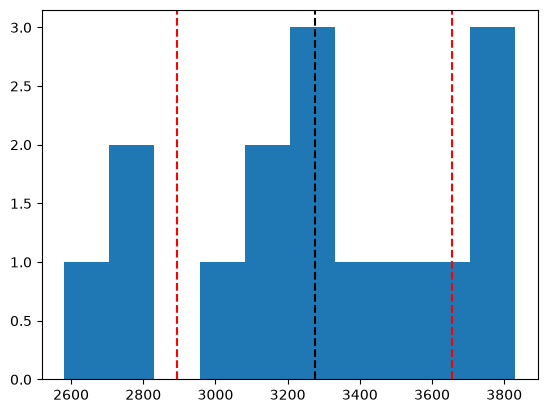

In [20]:
f,a = plt.subplots()
v0s = pwvi.dataset.fitres.sel(statistic = 'estimate', parameter = 'V0')
a.hist(v0s, bins = 10)
a.axvline(v0s.mean(), ls = '--', color = 'black')
a.axvline(v0s.mean() + v0s.std(), ls = '--', color = 'red')
a.axvline(v0s.mean() - v0s.std(), ls = '--', color = 'red')

## remove outliers

## at individual stderr

In [21]:


pwvitrunc = pwvi.remove_V0_with_large_uncertainties()
pwvitrunc = pwvitrunc.remove_V0_outliers()

In [22]:
pwvitrunc = copy.deepcopy(pwvi)
ds = pwvitrunc.dataset

ds = ds.sortby(ds.fitres.sel(statistic = 'uncertainty', parameter = 'V0'))

# remove data with largest uncertainty
stderr = ds.fitres.sel(statistic = 'uncertainty', parameter = 'V0')
dst = ds.where(stderr < stderr.quantile(0.9, dim = 'datetime'))
# pwvi.dataset.fitres


upper = dst.fitres.sel(statistic = 'estimate', parameter = 'V0').quantile(0.9, dim = 'datetime')

lower = dst.fitres.sel(statistic = 'estimate', parameter = 'V0').quantile(0.1, dim = 'datetime')


dat= dst.fitres.sel(statistic = 'estimate', parameter = 'V0')
dst = dst.where(np.logical_and(dat<upper, dat>lower))
pwvitrunc.dataset = dst

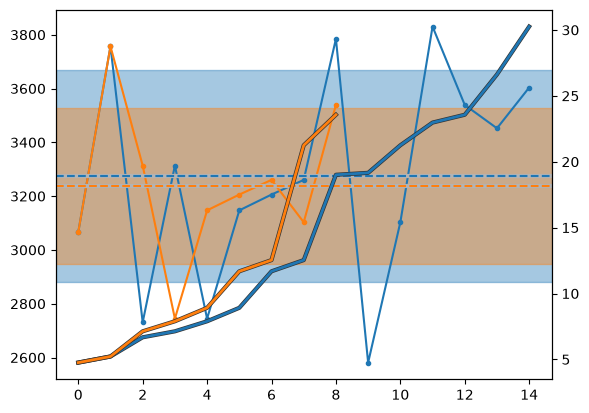

In [23]:
ds  = pwvi.dataset
ds = ds.sortby(ds.fitres.sel(statistic = 'uncertainty', parameter = 'V0'))
dst  = pwvitrunc.dataset
dst = dst.sortby(dst.fitres.sel(statistic = 'uncertainty', parameter = 'V0'))

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
f,a = plt.subplots()
a.plot(ds.fitres.sel(statistic = 'estimate', parameter = 'V0').data, color = colors[0], marker = '.')
a.plot(dst.fitres.dropna('datetime').sel(statistic = 'estimate', parameter = 'V0').data, color = colors[1], marker = '.')

bgcol = '0.7'
a.axhline(pwvi.V0_simple.V0, color = bgcol, ls = '-',lw = 3)
a.axhline(pwvi.V0_simple.V0, color = colors[0], ls = '--', lw = 1.5)
plt.axhspan(pwvi.V0_simple.V0 - pwvi.V0_simple.V0_std, pwvi.V0_simple.V0 + pwvi.V0_simple.V0_std, color = colors[0], alpha = 0.4, zorder = 0)
a.axhline(pwvitrunc.V0_simple.V0, color = bgcol, ls = '-',lw = 3)
a.axhline(pwvitrunc.V0_simple.V0, xmax = dst.fitres.shape[0],color = colors[1], ls = '--', lw = 1.5)
plt.axhspan(pwvitrunc.V0_simple.V0 - pwvitrunc.V0_simple.V0_std, pwvitrunc.V0_simple.V0 + pwvitrunc.V0_simple.V0_std, color = colors[1], alpha = 0.4, zorder = 0)

#####
bgcol= colors[-1]
bgcol = '0.2'
at = a.twinx()
at.plot(ds.fitres.sel(statistic = 'uncertainty', parameter = 'V0').data, color = bgcol, lw = 3)
at.plot(ds.fitres.sel(statistic = 'uncertainty', parameter = 'V0').data,color = colors[0], lw = 2)

at.plot(dst.fitres.dropna('datetime').sel(statistic = 'uncertainty', parameter = 'V0').data, color = bgcol, lw = 3)
at.plot(dst.fitres.dropna('datetime').sel(statistic = 'uncertainty', parameter = 'V0').data,color = colors[1], lw = 2)

# merge lang and pwv

In [24]:
dssave = lttrunc.V0_simple.copy()#.drop_vars('quantile')

In [25]:
dssave.loc[{'wavelength': 940}] = pwvitrunc.V0_simple

In [26]:
dssave.loc[{'wavelength': 940}]

<xarray.Dataset> Size: 64B
Dimensions:                              ()
Coordinates:
    wavelength                           int64 8B 940
    quantile                             float64 8B 0.9
Data variables:
    V0                                   float64 8B 3.237e+03
    V0_std                               float64 8B 288.7
    number_of_cals                       int64 8B 9
    one_sided_upper_bound_factor_95conf  float64 8B 1.711
    OD_uncertainty                       float64 8B 0.1576
    V0_stderr                            float64 8B 11.44

In [28]:
dssave = dssave.drop_vars('quantile')

# Save calibration

In [31]:
p2f = pl.Path().resolve() / f'data/V0_simple_{serialno}_v{version}.nc'
if p2f.exists():
    print(f'File already exists: {p2f}')
else:
    dssave.to_netcdf(p2f)
    print(f'Saved to {p2f}')

Saved to /Users/htelg/projects/cmpaign_2025_PMOD/data/V0_simple_648_v0.6.nc


In [30]:
# p2f.unlink()